Name Muhtasim Haque Nahian

Labpartner(s) Haoxin Ni

In [2]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

**For today's lab you need to install the package cartopy**

In [ ]:
# you can install packages here in a notebook with pip or conda, 
# or in the anaconda navigator in the environments tab (reccommended)
# pip install cartopy
# conda install cartopy

In [ ]:
# I had an old version of cartopy so I had to upgrade:
# pip install --upgrade cartopy

In [3]:
import cartopy.crs as ccrs   #import map styles/types
import cartopy.feature as cfeature  # features such as the ocean, coastlines rivers, etc

# Class 6.2

Today we will finish fiunction sharing and do more plotting

# Warmups 6.2

**W.1** Write some code that generates 15 random integers from 1-100. If the integers are divisible by 2 assign them to list "x" if they are divisible by three, assign them to list "y", if they are neither assign them to list "z". 

In [8]:
numbers = [random.randint(1, 100) for _ in range(15)]

x = []
y = []
z = []

for number in numbers:
    if number % 2 == 0:
        x.append(number)
    if number % 3 == 0:
        y.append(number)
    if number % 2 != 0 and number % 3 != 0:
        z.append(number)

print("Random integers:", numbers)
print("Divisible by 2 (x):", x)
print("Divisible by 3 (y):", y)
print("Neither (z):", z)

Random integers: [48, 56, 76, 97, 6, 50, 95, 41, 90, 51, 77, 71, 62, 54, 8]
Divisible by 2 (x): [48, 56, 76, 6, 50, 90, 62, 54, 8]
Divisible by 3 (y): [48, 6, 90, 51, 54]
Neither (z): [97, 95, 41, 77, 71]


# Lecture 6.2

### Agenda:

- Show us your functions
- Questions
- xarray package and plotting netcdf files


### Show us your functions (from Lab 5.2) - continued

### Questions

### Cartopy

Let's take the data we used last time and make the plot publication ready

There are a number of differnt map projections available in Cartopy.  
https://cartopy.readthedocs.io/stable/reference/projections.html
Robinson is often used for global maps

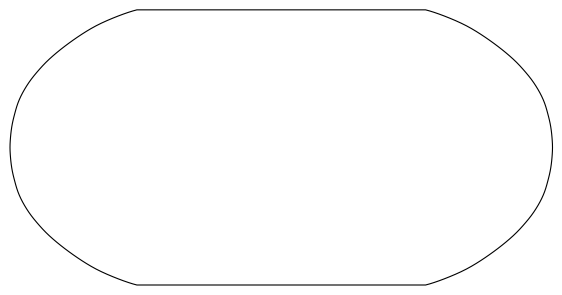

In [15]:
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson())  

#boring right? watch next :D

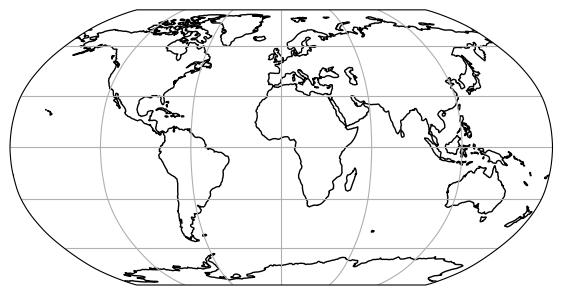

In [14]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson())     #robinson is a type of projection mostly for the oceanography peep
ax.coastlines(resolution='110m')
ax.gridlines()

When we are plotting ocean data, we like to make the Pacific contiguous, let's rotate

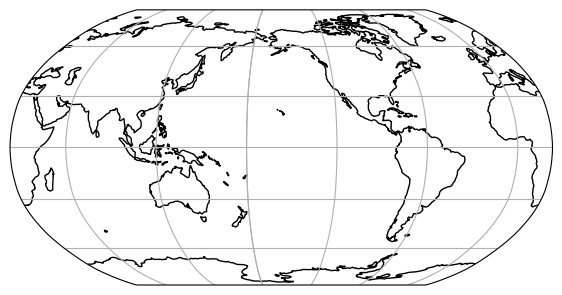

In [16]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = 203)) # this rotates the map to 203 degrees East
ax.coastlines(resolution='110m')
ax.gridlines()

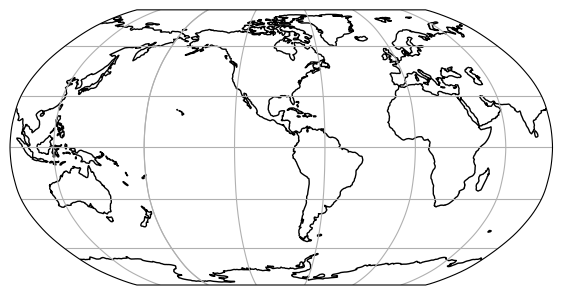

In [21]:
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = 360-89)) # this rotates the map to 203 degrees East
ax.coastlines(resolution='110m')
ax.gridlines()

Or we can rotate it so that it cuts through Indonesia (not good for mangrove or coral work)

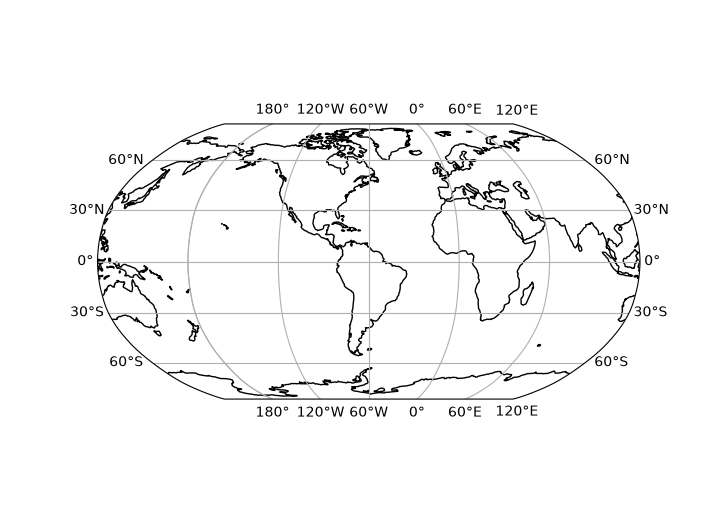

In [22]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = -60))
# -60 (60 W) is the same as 300 E (360 degrees in total 360-60W = 300E)
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True) # let's add some labels

Let's try some different map projections

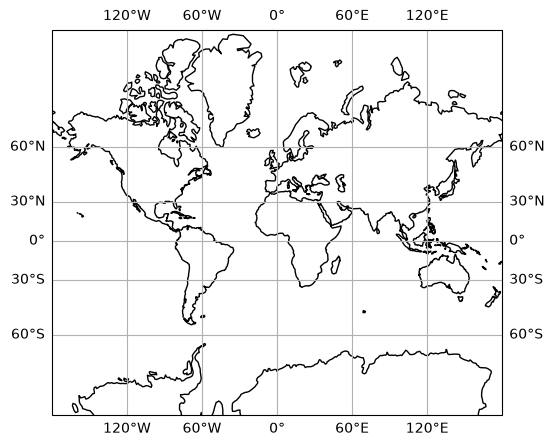

In [24]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Mercator()) # different map projection
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)

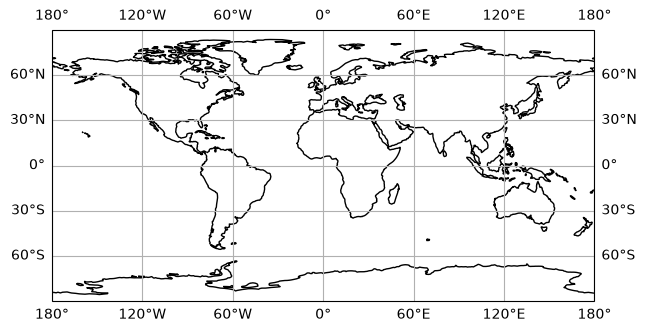

In [25]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)

How do I zoom in?

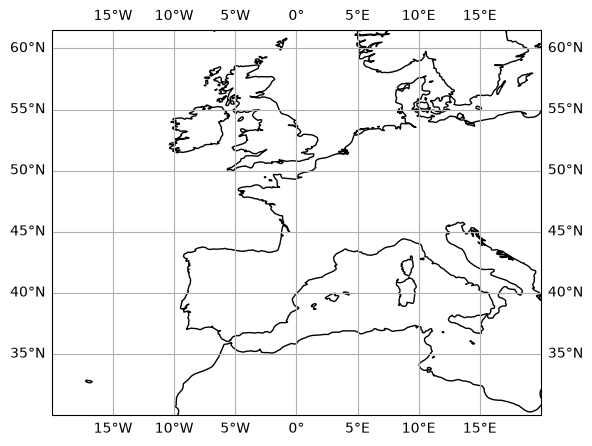

In [34]:
# let's zoom in to S Asia
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-20, 20, 30, 60]) # set the limits of the plot [lon_min, lon_max, lat_min, lat_max]
ax.coastlines(resolution='50m')
ax.gridlines(draw_labels=True)

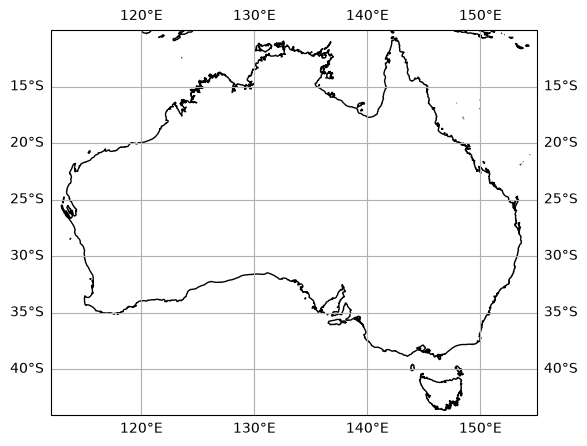

In [58]:
# make a plot of Australia

plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([112, 155, -10, -42]) # set the limits of the plot
ax.coastlines(resolution='10m')
ax.gridlines(draw_labels=True)



#### Moving back to the Gulf of Mexico, we want to set the lat and lon range to match our HYCOM data. How do we find this?

In [85]:
#insert path or url to file here
# download from the internet:
link = "https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_2d.nc"

In [86]:
gom_data = xr.open_dataset(link, decode_times=False)

In [87]:
gom_data

<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 4.566e+04
    Date                   (MT) float64 8B ...
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    Conventions:                     CF-1.6
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf2d
    comment:                         p-grid
    DODS_EXTRA.Unlimited_Dimension:  MT

In [88]:
gom_data.Date

<xarray.DataArray 'Date' (MT: 1)> Size: 8B
[1 values with dtype=float64]
Coordinates:
  * MT       (MT) float64 8B 4.566e+04
    Date     (MT) float64 8B ...
Attributes:
    units:           day as %Y%m%d.%f
    C_format:        %13.4f
    FORTRAN_format:  (f13.4)
    long_name:       date
    _ChunkSizes:     512

In [89]:
gom_data.MT

<xarray.DataArray 'MT' (MT: 1)> Size: 8B
array([45657.])
Coordinates:
  * MT       (MT) float64 8B 4.566e+04
    Date     (MT) float64 8B ...
Attributes:
    long_name:    time
    units:        days since 1900-12-31 00:00:00
    calendar:     gregorian
    axis:         T
    _ChunkSizes:  512

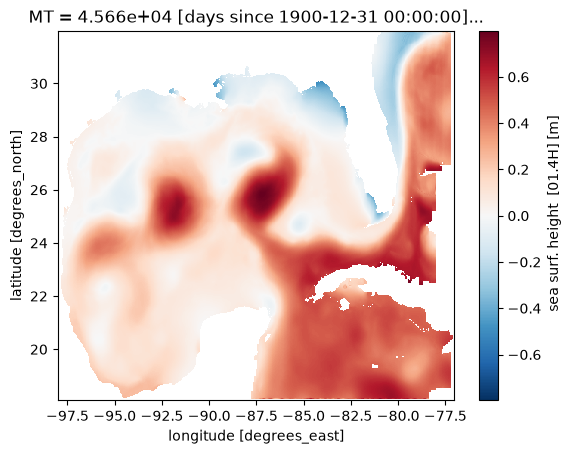

In [90]:
# let's remember what our data looked like, pick a variable to plot

gom_data.ssh.plot()

I'm going to get the max and min of the lat and lon to help me plot the data

In [91]:
lat_min = gom_data.Latitude.min()
print(lat_min)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(18.091648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [92]:
lat_max = gom_data.Latitude.max()
print(lat_max)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(31.960648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [93]:
lon_min = gom_data.Longitude.min()
print(lon_min)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-98., dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


In [94]:
lon_max = gom_data.Longitude.max()
print(lon_max)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-77.03998, dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


Now I can use them below

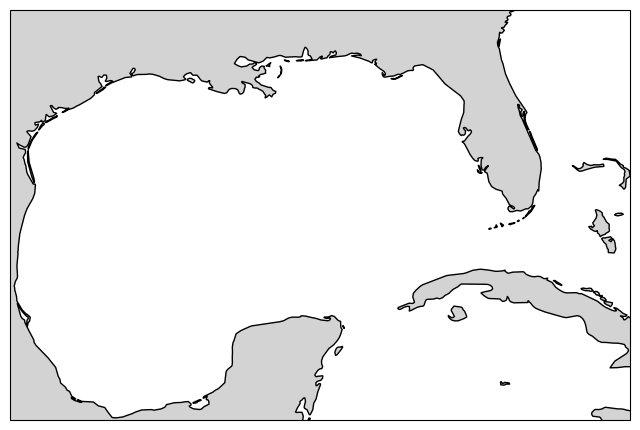

In [70]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='lightgrey')
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Let's make the land color a bit lighter gray

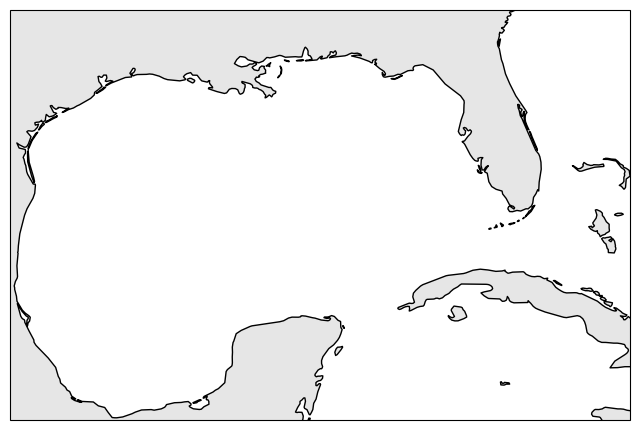

In [71]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9') # 0 is black and 1 is white
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

In [82]:
# let's figure out what var is

var = gom_data.ssh[0, :, :]     # to get rid of the time dimension

var

<xarray.DataArray 'ssh' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.566e+04
    Date       float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]

#### Now let's add some data

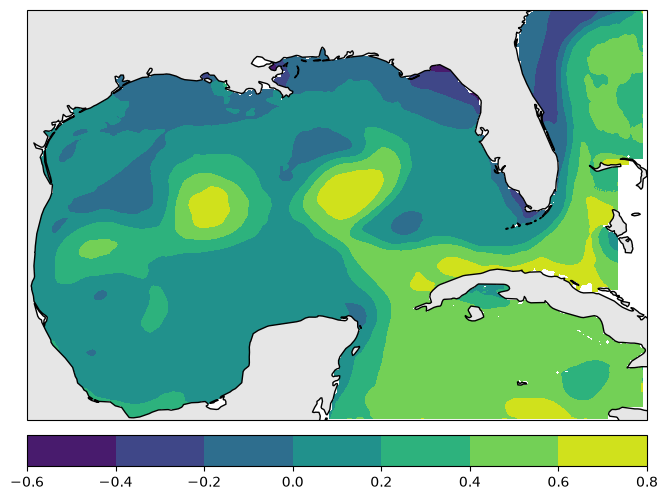

In [85]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# Contours the data on tho the map projection
p = ax.contourf(x, y, var, transform=ccrs.PlateCarree()) # projection is needed in every plot call  # var needs to be 2d for contourf

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


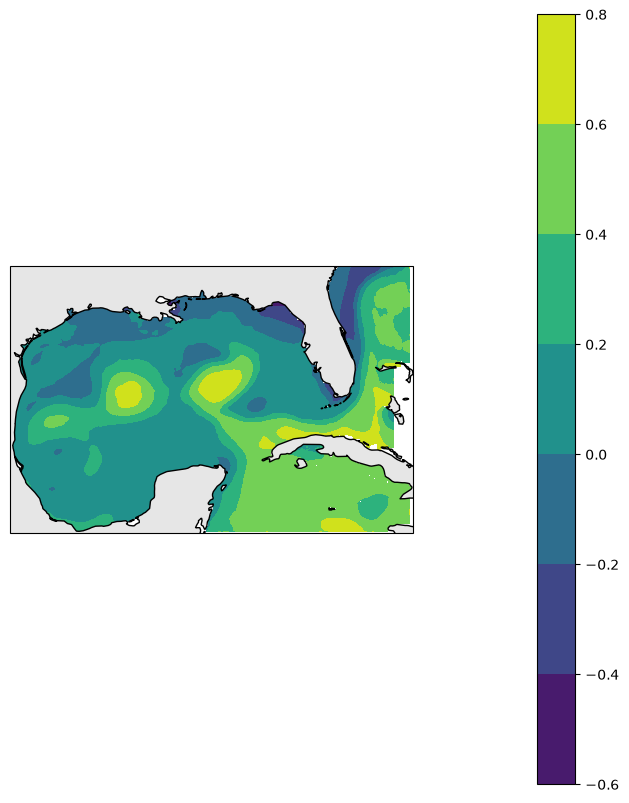

In [94]:

fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# Contours the data on tho the map projection
p = ax.contourf(x, y, var, transform=ccrs.PlateCarree()) # projection is needed in every plot call  # var needs to be 2d for contourf

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
cbar = plt.colorbar(p, pad=0.2)

#### Try taking out the options for the colorbar, what happens? What does "pad" do?

#### What is the range of our data?

In [95]:
print(var.max())

<xarray.DataArray 'ssh' ()> Size: 4B
array(0.7986358, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]


In [96]:
print(var.min())

<xarray.DataArray 'ssh' ()> Size: 4B
array(-0.504511, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]


#### Let's set the countour levels to match our data range. I'm also going to change the colormap
See https://matplotlib.org/stable/users/explain/colors/colormaps.html
Note you can reverse any colormap by appending '_r' to the name

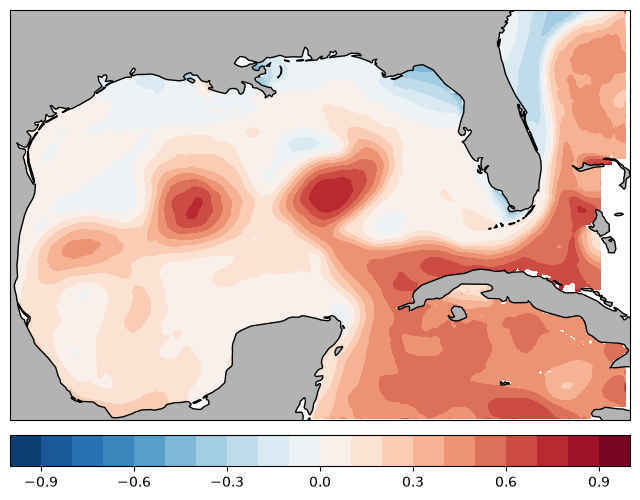

In [112]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]  

# let's fill in the range here:
step = np.arange(-1.0,1.1,0.1)     # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'RdBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


#### Okay, now let's add some labels

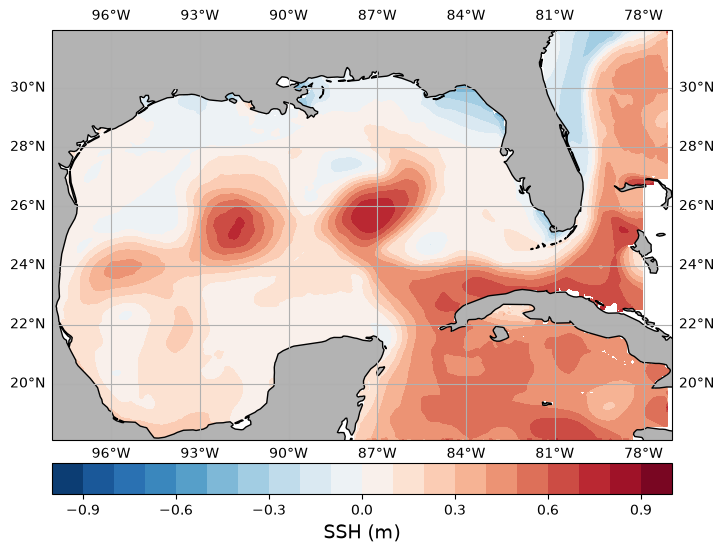

In [106]:
# copy in previous code here
# I'm also going to cut out the white bits at right by adjusting lon_max

fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]  

# let's fill in the range here:
step = np.arange(-1.0,1.1,0.1)     # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'RdBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.03)
cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)


#### These labels are too small for what I want. I need them to be much bigger.

In [ ]:
#Note we can easily make the lat/lon and colorbar font size bigger by adjusting the matplotlib parameters, 
# which I introduced last time
import matplotlib as mpl
mpl.rcParams['font.size'] = 14

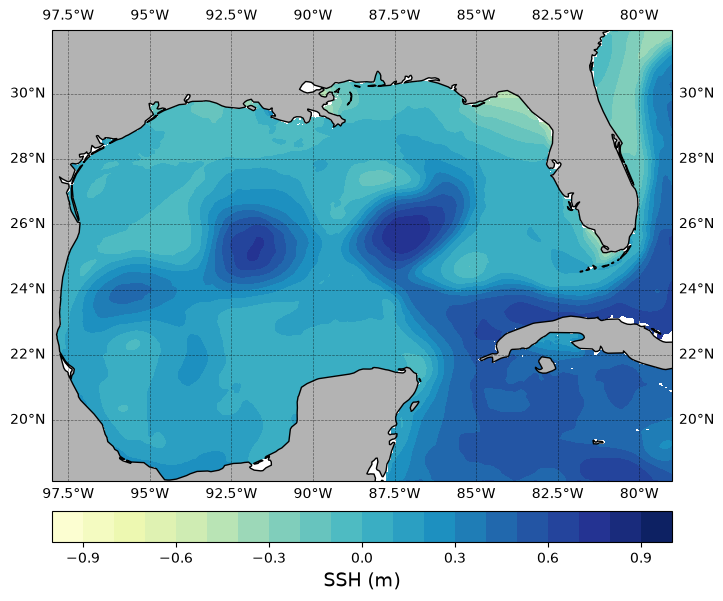

In [137]:
#exact same code as before
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, -79, 18.15, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]  

# let's fill in the range here:
step = np.arange(-1.0,1.1,0.1)     # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'YlGnBu', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.04)
cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True, color="black", linestyle="--", linewidth=0.5, alpha=0.5)

#### Not bad

## Lab 6.2

**E.0** Finish Lab 6.1 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 3-4. Let me know if this feels like a good pace

**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

In [44]:
# loading the datasets for practice

seattle_weather = pd.read_csv("https://assets.datacamp.com/production/repositories/3634/datasets/6fd451508ecce0d63354fad86704236592eed8ca/seattle_weather.csv")
seattle_weather = seattle_weather[seattle_weather["NAME"] == "SEATTLE TACOMA INTERNATIONAL AIRPORT, WA US"].copy()
seattle_weather["MONTH"] = pd.to_datetime(seattle_weather["DATE"], format="%m").dt.strftime("%b")

austin_weather = pd.read_csv("https://assets.datacamp.com/production/repositories/3634/datasets/e76b460b41dc7ff286d78246daf3a8c324cb5587/austin_weather.csv")
austin_weather["MONTH"] = pd.to_datetime(austin_weather["DATE"], format="%m").dt.strftime("%b")

climate_change = pd.read_csv("https://assets.datacamp.com/production/repositories/3634/datasets/411add3f8570d5adf891127fd64095020210711b/climate_change.csv", parse_dates=["date"], index_col="date")

medals = pd.read_csv("https://assets.datacamp.com/production/repositories/3634/datasets/ec663f9f509bf633d40932f65bd4cc51205689e2/medals_by_country_2016.csv", index_col=0)

summer_2016_medals = pd.read_csv("https://assets.datacamp.com/production/repositories/3634/datasets/67d7344085ace400d612275b87738615698127a3/summer2016.csv", index_col=0)
mens_rowing = summer_2016_medals[(summer_2016_medals["Sex"] == "M") & (summer_2016_medals["Sport"] == "Rowing")]
mens_gymnastics = summer_2016_medals[(summer_2016_medals["Sex"] == "M") & (summer_2016_medals["Sport"] == "Gymnastics")]

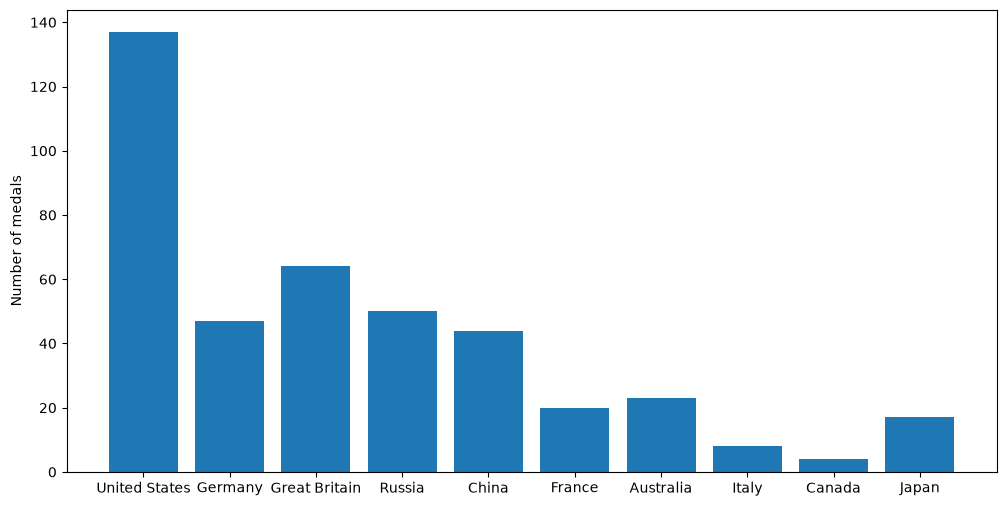

In [31]:
# bar chart

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(medals.index, medals["Gold"])

ax.set_ylabel("Number of medals")

plt.show()

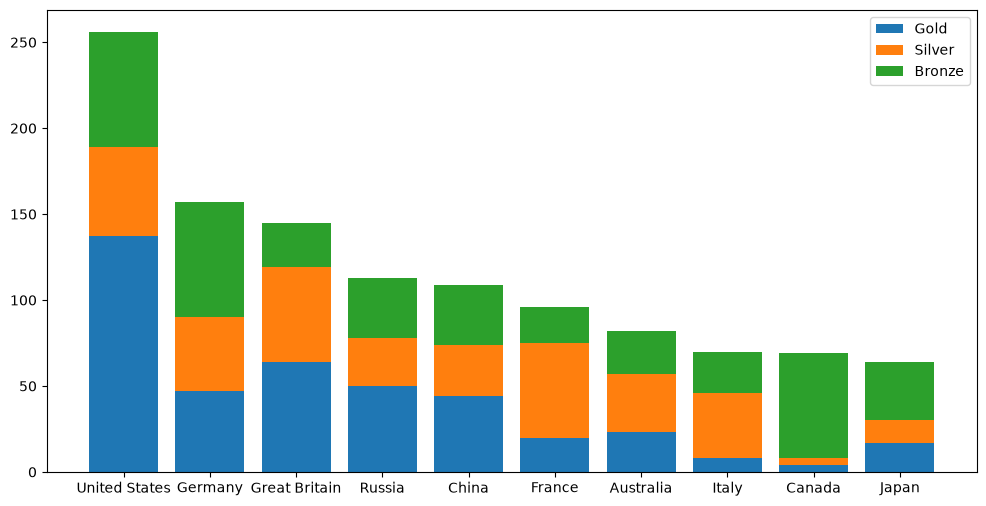

In [24]:
# stacked bar

fig, ax = plt.subplots(figsize=(12,6))

# adding bars for bronze on top of silver and that on top of gold
ax.bar(medals.index, medals["Gold"], label="Gold")
ax.bar(medals.index, medals["Silver"], bottom=medals["Gold"], label="Silver")
ax.bar(medals.index, medals["Bronze"], bottom=medals["Gold"] + medals["Silver"], label="Bronze")

ax.legend()
plt.show()

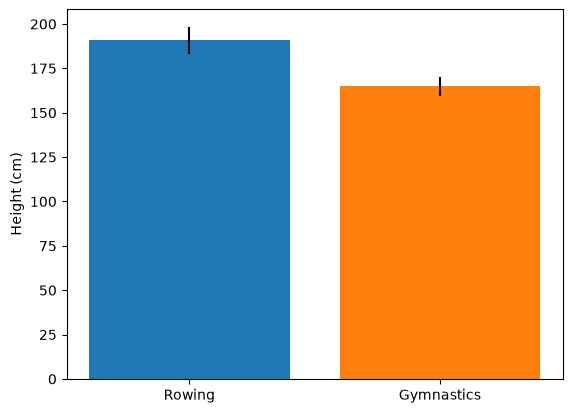

In [37]:
# adding error-bars to a bar chart

fig, ax = plt.subplots()

# using yerr to add std/mean
ax.bar("Rowing", mens_rowing["Height"].mean(), yerr=mens_rowing["Height"].std())
ax.bar("Gymnastics", mens_gymnastics["Height"].mean(), yerr=mens_gymnastics["Height"].std())

ax.set_ylabel("Height (cm)")

plt.show()

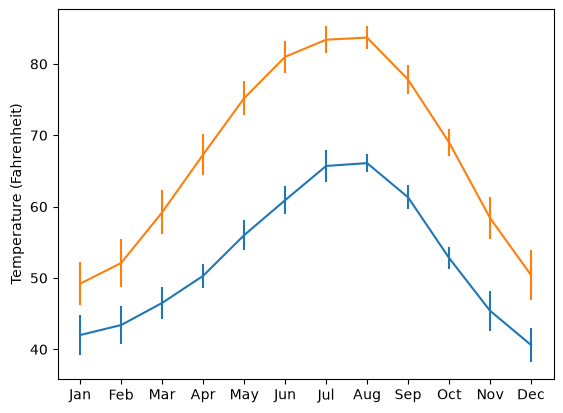

In [32]:
# adding error-bars to a plot

fig, ax = plt.subplots()

# using ax.errorbar() to add yerr
ax.errorbar(seattle_weather["MONTH"], seattle_weather["MLY-TAVG-NORMAL"], yerr=seattle_weather["MLY-TAVG-STDDEV"])
ax.errorbar(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"], yerr=austin_weather["MLY-TAVG-STDDEV"])

ax.set_ylabel("Temperature (Fahrenheit)")

plt.show()

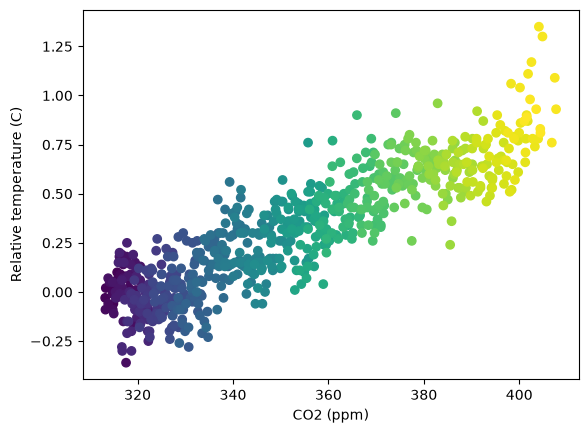

In [45]:
# scatter plot (encoding time index by color)

fig, ax = plt.subplots()

ax.scatter(climate_change["co2"], climate_change["relative_temp"], c=climate_change.index)  # c for encoding by color

ax.set_xlabel("CO2 (ppm)")
ax.set_ylabel("Relative temperature (C)")

plt.show()

In [42]:
# ax.hist for histogram
# ax.boxplot for boxplot

**E.3** Make a plot of a different variable for the HYCOM data. Play around with colormaps and contourlines to make it your own. Post your plot on the class slack #programming channel

In [17]:
# Load the HYCOM file from your Jupyter directory
src = ("https://tds.hycom.org/thredds/dodsC/datasets/GOMb0.04/reanalysis/data/2019/031_archv.2019_137_00_3z.nc")
ds = xr.open_dataset(src, engine="netcdf4", decode_times=False)
ds

<xarray.Dataset> Size: 162MB
Dimensions:     (MT: 1, Depth: 40, Latitude: 385, Longitude: 525)
Coordinates:
  * MT          (MT) float64 8B 4.324e+04
    Date        (MT) float64 8B ...
  * Depth       (Depth) float32 160B 0.0 2.0 4.0 6.0 ... 3e+03 4e+03 5e+03
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Data variables:
    u           (MT, Depth, Latitude, Longitude) float32 32MB ...
    v           (MT, Depth, Latitude, Longitude) float32 32MB ...
    w_velocity  (MT, Depth, Latitude, Longitude) float32 32MB ...
    water_temp  (MT, Depth, Latitude, Longitude) float32 32MB ...
    salinity    (MT, Depth, Latitude, Longitude) float32 32MB ...
Attributes:
    Conventions:                     CF-1.0
    source:                          HYCOM archive file
    experiment:                      01.0
    history:                         python
    title:                           HYCOM
    DODS_EXTRA.Unlimited_Dimension:  MT

In [22]:
print("Valid grid cells:", salinity.count().item())
print("Minimum salinity:", salinity.min().item())
print("Maximum salinity:", salinity.max().item())

Valid grid cells: 103044
Minimum salinity: 35.80172348022461
Maximum salinity: 39.83108139038086


In [50]:
salinity = ds["salinity"].sel(Depth=200, method="nearest").isel(MT=0)
salinity = salinity.where(salinity < 1e10)

salinity

<xarray.DataArray 'salinity' (Latitude: 385, Longitude: 525)> Size: 808kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(385, 525), dtype=float32)
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.324e+04
    Date       float64 8B 2.019e+07
    Depth      float32 4B 200.0
Attributes:
    long_name:      salinity [01.0H]
    standard_name:  sea_water_salinity
    units:          psu
    valid_range:    [ 0.1722538 40.8976805]
    _ChunkSizes:    [  1  20 193 263]

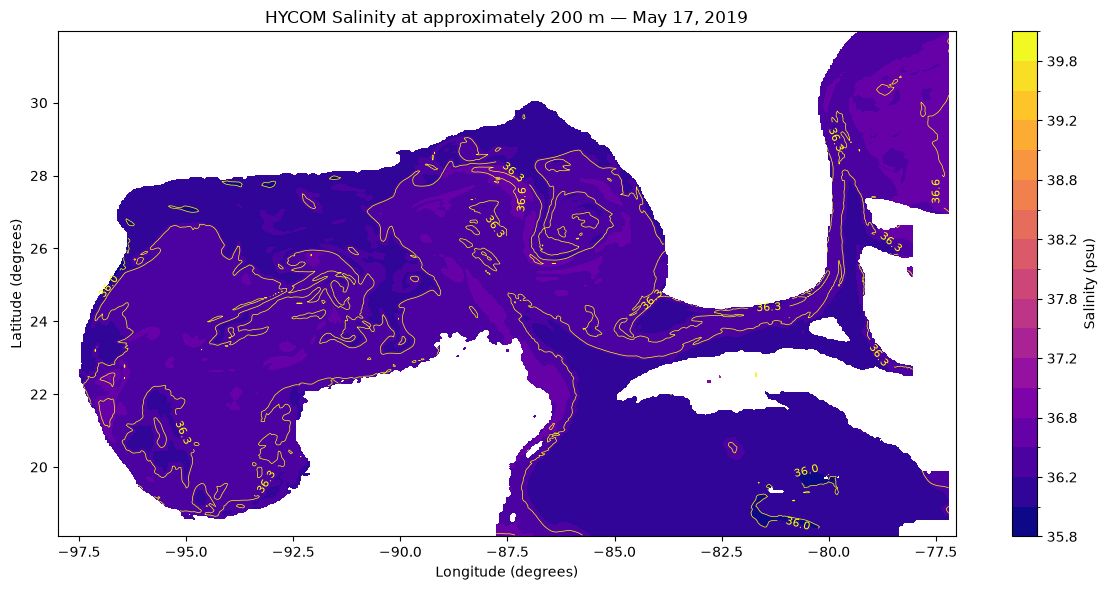

In [186]:
fig, ax = plt.subplots(figsize=(12, 6))

salinity.plot.contourf(ax=ax, x="Longitude", y="Latitude", levels=20, cmap="plasma", cbar_kwargs={"label": "Salinity (psu)", "format": "%.1f"})

lines = salinity.plot.contour(ax=ax, x="Longitude", y="Latitude", levels=15, colors="yellow", linewidths=0.5)

ax.clabel(lines, fontsize=8, fmt="%.1f")
ax.set_title("HYCOM Salinity at approximately 200 m — May 17, 2019")
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Latitude (degrees)")

plt.tight_layout()
plt.show()

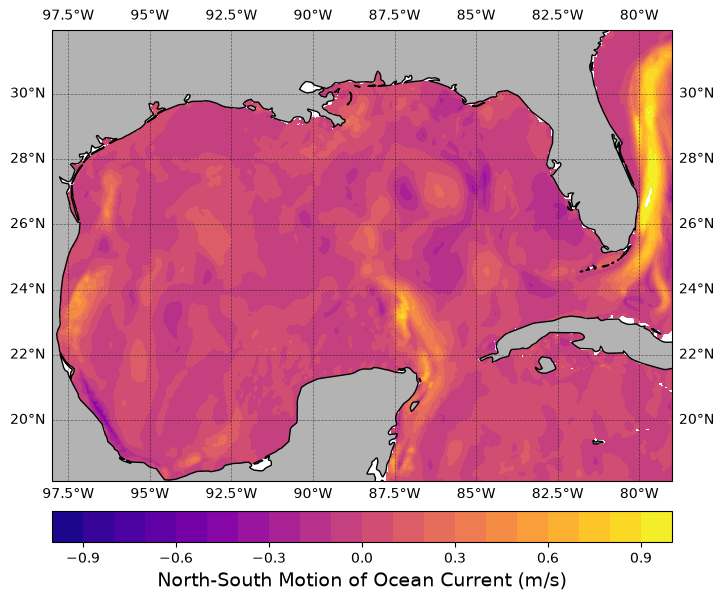

In [189]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, -79, 18.15, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.v_barotropic_velocity[0,:,:]  

step = np.arange(-1.0,1.1,0.1)    
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'plasma', 
                    levels = step)

cbar = plt.colorbar(p, orientation='horizontal', pad=0.04)
cbar.set_label("North-South Motion of Ocean Current" +' (m/s)', size = 14)

ax.gridlines(draw_labels=True, color="black", linestyle="--", linewidth=0.5, alpha=0.5)

fig.savefig("HYCOM_v_bar_vel.png", dpi=300, bbox_inches="tight")

###### This week's project:

#### Note you might want to restart your kernel at this point to dump all the hycom data from memory. Just reload the packages you need

**E.4** Download some data from the ISIMIP data archive (https://data.isimip.org/) and plot it using cartopy. ISIMIP provides bias-corrected daata for past and future climate simulations used for impacts studies world wide. Let's start with some maximum atmospheric surface temperature data in the historical period (1850-2014 for CMIP6). We want climate forcing data for ISIMIP3b, which are the lastest (CMIP6) climate projections. 

* https://data.isimip.org/search/tree/ISIMIP3b/InputData/climate/
* Click atmopsheric forcing
* Click GFDL... This is one of NOAA-GFDL's climate models (ESM4)
* Click historical

All of the variable names are in CMIP lingo. Sadly, there is no easy cheat sheet. But you want tas, which is "temperature of air at surface". Let's use the tasmax, the maximum daily surface air temperature
* Click tasmax
* Click files to see all the available files.
  
Here you have a choice, you can download an etire file (note the size) or you can use the "configure download" button, which has subsetting by space or country, as well as time opitons. You can click on a file name to see more info.
* Click on "download file" for the 1851-1860 file. Just grab the whole file, it will take a minute to download.
* Load up the data into xarray and plot the maximum of this dataset (so max over the decade for each gridcell. You just use a max function for this, no loops needed).
* Plot using cartopy to make it pretty. Put some sensible lables on it, etc. Maybe add some country boundaries.

In [108]:
path= r"E:\_MS LSU\OCS 7001 Scientific Computing\gfdl-esm4_r1i1p1f1_w5e5_historical_tasmax_global_daily_1851_1860.nc"
data = xr.open_dataset(path, decode_times=False)
data

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 3653, lat: 360, lon: 720)
Coordinates:
  * time     (time) float64 29kB 0.0 1.0 2.0 ... 3.65e+03 3.651e+03 3.652e+03
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Data variables:
    tasmax   (time, lat, lon) float32 4GB ...
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [172]:
# process chunks sequentially to limit memory use :))

data = xr.open_dataset(path, decode_times=False, chunks={"time": 30})

tasmax_decade = data["tasmax"].max(dim="time", keep_attrs=True).compute(scheduler="single-threaded")

tasmax_decade = data["tasmax"].max(dim="time")

In [173]:
# K to C
units = data["tasmax"].attrs.get("units", "")
if units.lower() in ["k", "kelvin"]:
    tasmax_decade = tasmax_decade - 273.15
    units = "°C"

print("Historical temperature range (°C):")
print("Minimum:", tasmax_decade.min().compute().item())
print("Maximum:", tasmax_decade.max().compute().item())

Historical temperature range (°C):
Minimum: -21.3834228515625
Maximum: 52.400115966796875


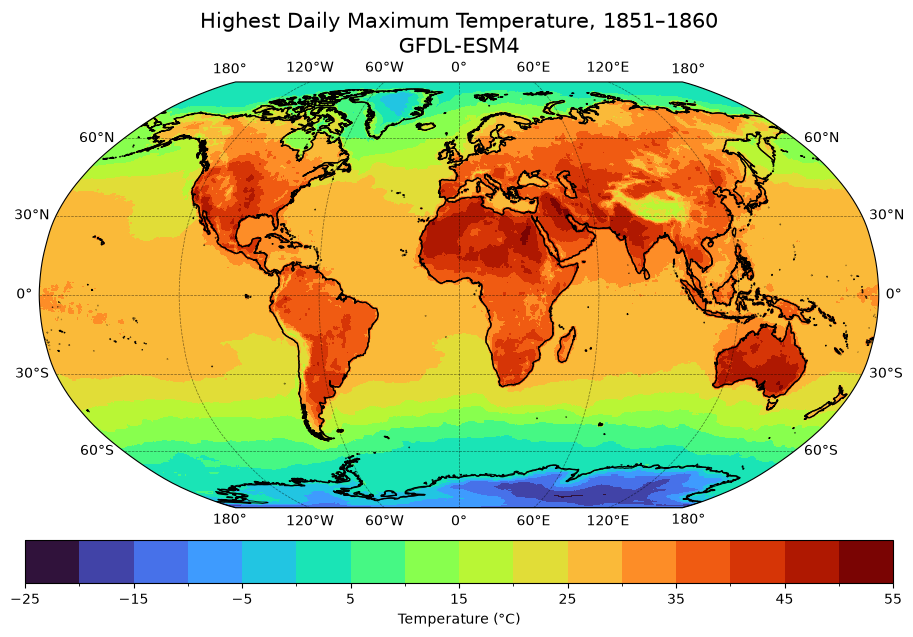

In [190]:
# global Cartopy map
fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={"projection": ccrs.Robinson()})

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black', facecolor = 'none')

tasmax_decade.plot.contourf(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap="turbo", levels = np.arange(-25, 56, 5),
    cbar_kwargs={"label": f"Temperature ({units})", "orientation": "horizontal", "pad": 0.06, "shrink": 0.8, "ticks": np.arange(-25, 56, 10)})

ax.set_global()
ax.coastlines(linewidth=0.6)
ax.add_feature(land_50m)
ax.gridlines(draw_labels=True, color="black", linestyle="--", linewidth=0.5, alpha=0.5)

ax.set_title("Highest Daily Maximum Temperature, 1851–1860\nGFDL-ESM4", size = 15)

plt.show()

**E.5** Now make a second plot using ISIMP data for a future climate projection. Following the same steps as above, get the GFDL tasmax data for the future climate scenario SSP3-7.0 (higher emissions scenario) for 2051-2060. Again, calculate the maximum at each gridpoint for this data set. This is the future maximum daily temperature for that decade. Make your plot nice.

In [195]:
path1 = r"E:\_MS LSU\OCS 7001 Scientific Computing\gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmax_global_daily_2051_2060.nc"

future = xr.open_dataset(path1, decode_times=False, chunks={"time": 30})

tasmax_fut = future["tasmax"].max(dim="time", keep_attrs=True).compute(scheduler="single-threaded")

In [196]:
units_f = future["tasmax"].attrs.get("units", "")
if units_f.lower() in ["k", "kelvin"]:
    tasmax_fut = tasmax_fut - 273.15
    units_f = "°C"

print("Future temperature range (°C):")
print("Minimum:", tasmax_fut.min().compute().item())
print("Maximum:", tasmax_fut.max().compute().item())

Future temperature range (°C):
Minimum: -19.48101806640625
Maximum: 55.42626953125


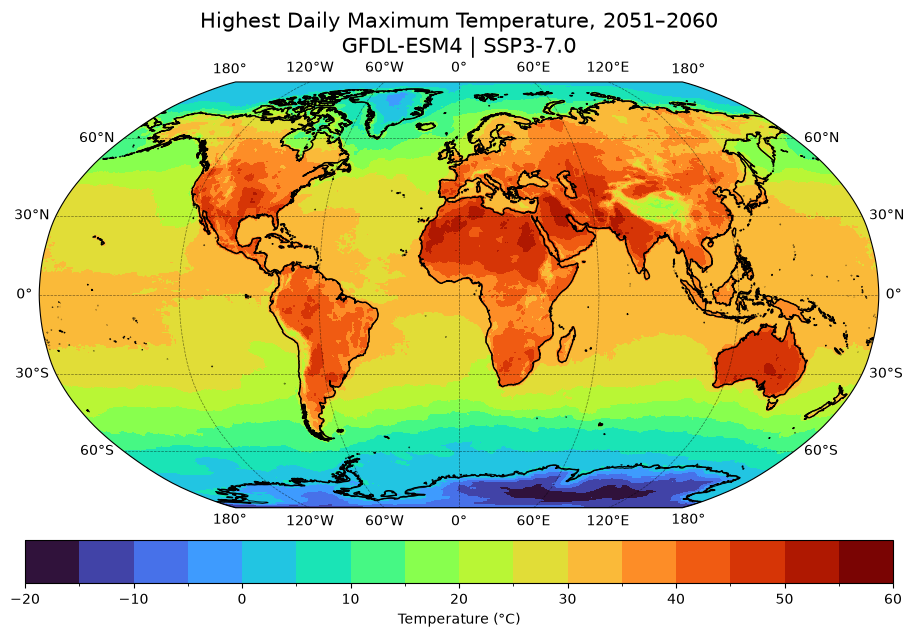

In [197]:
fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={"projection": ccrs.Robinson()})

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black',facecolor = 'none')

tasmax_fut.plot.contourf(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap="turbo", levels = np.arange(-20, 61, 5),
    cbar_kwargs={"label": f"Temperature ({units})", "orientation": "horizontal", "pad": 0.06, "shrink": 0.8, "ticks": np.arange(-20, 61, 10)})

ax.set_global()
ax.coastlines(linewidth=0.6)
ax.add_feature(land_50m)
ax.gridlines(draw_labels=True, color="black", linestyle="--", linewidth=0.5, alpha=0.5)

ax.set_title("Highest Daily Maximum Temperature, 2051–2060\n"
    "GFDL-ESM4 | SSP3-7.0", size = 15)

plt.show()

**E.6** Now plot the anomaly between the two, 2050's - 1850's. Use a diverging colormap (light in the middle), centered on zero. What is the outlook for your country of orgin? Answer in full sentances with specific numbers.

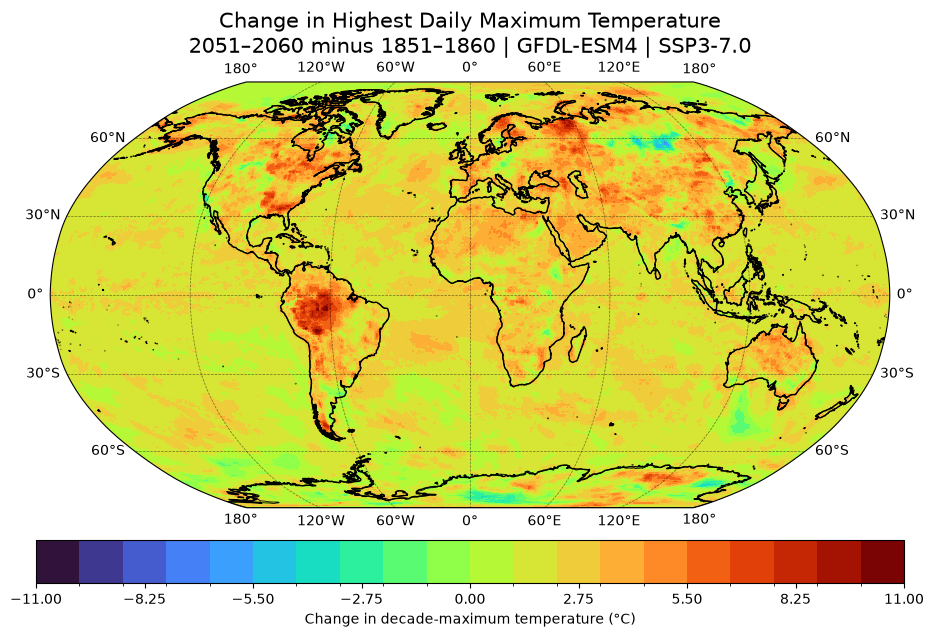

In [198]:
anomaly = tasmax_fut - tasmax_decade

# symmetric color range around zero
limit = max(1, np.ceil(np.abs(anomaly).max().compute().item()))
levels = np.linspace(-limit, limit, 21)
ticks = np.linspace(-limit, limit, 9)

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor = 'black',facecolor = 'none')

# global anomaly map
fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={"projection": ccrs.Robinson()})

anomaly.plot.contourf(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap="turbo", levels=levels, vmin=-limit, vmax=limit,
    cbar_kwargs={"label": "Change in decade-maximum temperature (°C)", "orientation": "horizontal", "pad": 0.06, "shrink": 0.8, "ticks": ticks})

ax.set_global()
ax.coastlines(resolution="110m", linewidth=0.6)
ax.add_feature(land_50m)
ax.gridlines(draw_labels=True, color="black", linestyle="--", linewidth=0.5, alpha=0.5)

ax.set_title("Change in Highest Daily Maximum Temperature\n"
    "2051–2060 minus 1851–1860 | GFDL-ESM4 | SSP3-7.0", size=15)

plt.show()

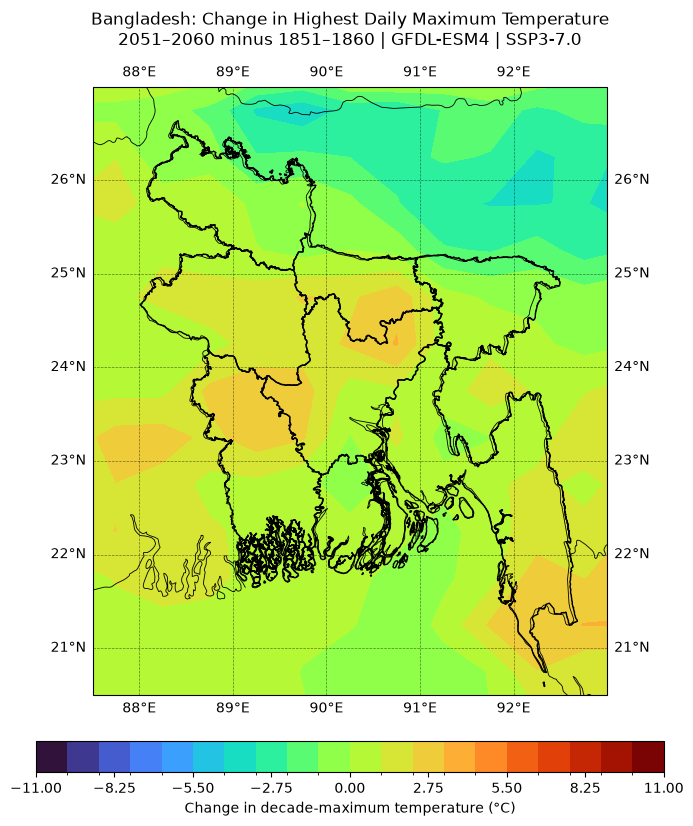

In [209]:
import requests
from shapely.geometry import shape

# some extra works to look Bangladesh a bit more visually detailed :))
# load Bangladesh division boundaries
url = ("https://gis.dghs.gov.bd/server/rest/services/Hosted/""bgd_admbnda_adm1_bbs_20201113/FeatureServer/0/query")
response = requests.get(url, params={"where": "1=1", "outFields": "adm1_en", "outSR": 4326,"f": "geojson"}, timeout=60)
response.raise_for_status()
divisions = response.json()["features"]

anomaly_bd = anomaly.sortby("lat").sortby("lon").sel(lon=slice(87, 94), lat=slice(20, 28)).compute(scheduler="single-threaded")

# symmetric scale, matching the global anomaly map
limit = max(1, np.ceil(np.abs(anomaly).max().compute(scheduler="single-threaded").item()))
levels = np.linspace(-limit, limit, 21)
ticks = np.linspace(-limit, limit, 9)

fig, ax = plt.subplots(figsize=(9, 10), subplot_kw={"projection": ccrs.PlateCarree()})

anomaly_bd.plot.contourf(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap="turbo", levels=levels, vmin=-limit, vmax=limit,
    cbar_kwargs={"label": "Change in decade-maximum temperature (°C)", "orientation": "horizontal", "pad": 0.06, "shrink": 0.9, "ticks": ticks})

ax.set_extent([87.5, 93, 20.5, 27], crs=ccrs.PlateCarree())
ax.coastlines(resolution="10m", linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), edgecolor="black", linewidth=0.6)

# Bangladesh division boundaries and labels
for division in divisions:
    geometry = shape(division["geometry"])
    ax.add_geometries([geometry], crs=ccrs.PlateCarree(), facecolor="none", edgecolor="black", linewidth=1, zorder=5)

ax.set_title("Bangladesh: Change in Highest Daily Maximum Temperature\n"
    "2051–2060 minus 1851–1860 | GFDL-ESM4 | SSP3-7.0", size=12, pad=15)
ax.gridlines(draw_labels=True, color="black", linestyle="--", linewidth=0.5, alpha=0.5)

plt.show()

In [207]:
hist_bd = tasmax_decade.sortby("lat").sortby("lon").sel(lat=slice(20, 27), lon=slice(88, 93))
fut_bd = tasmax_fut.sortby("lat").sortby("lon").sel(lat=slice(20, 27), lon=slice(88, 93))
hist_bd, fut_bd = xr.align(hist_bd, fut_bd, join="exact")

bd_hist = hist_bd.where(valid).weighted(np.cos(np.deg2rad(hist_bd.lat))).mean(dim=("lat", "lon")).compute().item()
bd_fut = fut_bd.where(valid).weighted(np.cos(np.deg2rad(hist_bd.lat))).mean(dim=("lat", "lon")).compute().item()
change = bd_fut - bd_hist
direction = "increase" if change >= 0 else "decrease"

print(f"For Bangladesh, the area-weighted average of each grid cell's "f"highest daily maximum temperature rises from {bd_hist:.2f} °C "
    f"in 1851–1860 to {bd_fut:.2f} °C in 2051–2060 under SSP3-7.0. "f"This represents a projected {direction} of {abs(change):.2f} °C "
    f"in this measure of extreme heat.")

For Bangladesh, the area-weighted average of each grid cell's highest daily maximum temperature rises from 39.44 °C in 1851–1860 to 40.53 °C in 2051–2060 under SSP3-7.0. This represents a projected increase of 1.09 °C in this measure of extreme heat.


**E.7** How could you potentially use this kind of data (future climate projections) in your research? Do some brainstorming. Write down your thoughts here.

I could use future climate projections to study whether drainage systems in coastal Bangladesh can handle more extreme rainfall. Moreover, I could investigate how sea-level rise and heavy rainfall jointly affect drainage in coastal towns. I could also combine temperature and precipitation projections to identify communities facing both extreme heat and flood risks, using multiple climate models and scenarios to account for uncertainty.